In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [11]:
# ---------- DATA ----------

study_hours = [
    3, 4, 5, 5, 6, 7, 7, 8, 9, 10,
    2, 4, 4, 5, 6, 6, 7, 8, 9, 11,
    3, 5, 6, 7, 8, 8, 9, 10, 11, 12
]

study_method = [
    "Individual", "Individual", "Individual", "Individual", "Individual",
    "Individual", "Individual", "Individual", "Individual", "Individual",
    "Group", "Group", "Group", "Group", "Group",
    "Group", "Group", "Group", "Group", "Group",
    "Practice", "Practice", "Practice", "Practice", "Practice",
    "Practice", "Practice", "Practice", "Practice", "Practice"
]

teaching_method = [
    "Lecture", "Interactive", "Lecture", "Interactive", "Lecture",
    "Interactive", "Lecture", "Interactive", "Lecture", "Interactive",
    "Lecture", "Interactive", "Lecture", "Interactive", "Lecture",
    "Interactive", "Lecture", "Interactive", "Lecture", "Interactive",
    "Lecture", "Interactive", "Lecture", "Interactive", "Lecture",
    "Interactive", "Lecture", "Interactive", "Lecture", "Interactive"
]

attendance = [
    65, 70, 75, 78, 80, 82, 85, 88, 90, 92,
    60, 68, 72, 76, 80, 84, 86, 89, 91, 95,
    70, 75, 80, 83, 86, 88, 91, 93, 95, 97
]

previous_mark = [
    45, 48, 50, 52, 55, 58, 60, 63, 65, 68,
    42, 47, 50, 53, 56, 60, 62, 65, 68, 72,
    46, 50, 54, 58, 61, 64, 67, 70, 73, 76
]

marks = [
    45, 49, 53, 55, 60, 63, 67, 70, 74, 78,
    40, 47, 50, 55, 58, 62, 66, 69, 73, 79,
    48, 53, 58, 62, 66, 70, 74, 78, 82, 86
]

In [12]:
# ---------- CREATE DATAFRAME ----------

data = {
    "Study Hours": study_hours,
    "Study Method": study_method,
    "Teaching Method": teaching_method,
    "Attendance": attendance,
    "Previous Mark": previous_mark,
    "Final Mark": marks
}

df = pd.DataFrame(data)

df

,Study Hours,Study Method,Teaching Method,Attendance,Previous Mark,Final Mark
0,3,Individual,Lecture,65,45,45
1,4,Individual,Interactive,70,48,49
2,5,Individual,Lecture,75,50,53
3,5,Individual,Interactive,78,52,55
4,6,Individual,Lecture,80,55,60
5,7,Individual,Interactive,82,58,63
6,7,Individual,Lecture,85,60,67
7,8,Individual,Interactive,88,63,70
8,9,Individual,Lecture,90,65,74
9,10,Individual,Interactive,92,68,78


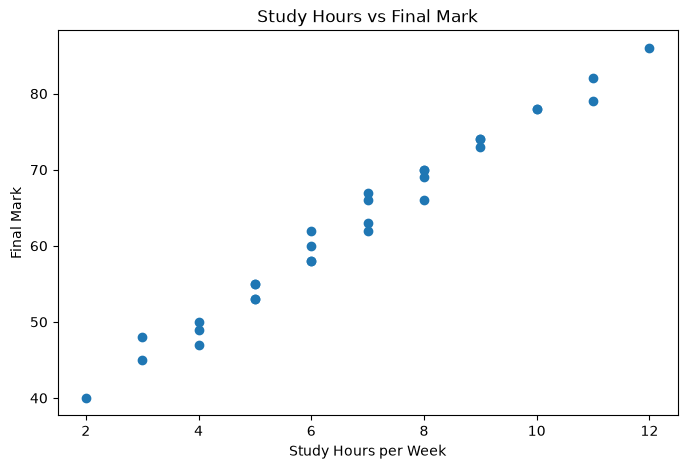

In [13]:
# ---------- SCATTER PLOT ----------

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study Hours"],
    df["Final Mark"]
)

plt.title("Study Hours vs Final Mark")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Mark")

plt.show()

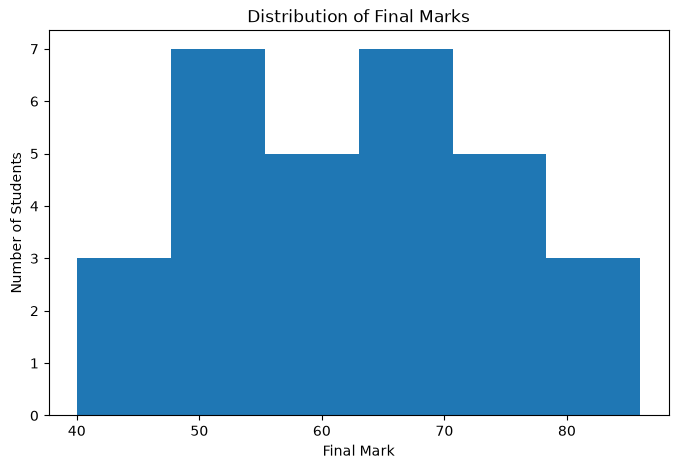

In [14]:
# ---------- HISTOGRAM ----------

plt.figure(figsize=(8, 5))

plt.hist(
    df["Final Mark"],
    bins=6
)

plt.title("Distribution of Final Marks")
plt.xlabel("Final Mark")
plt.ylabel("Number of Students")

plt.show()

<Figure size 800x500 with 0 Axes>

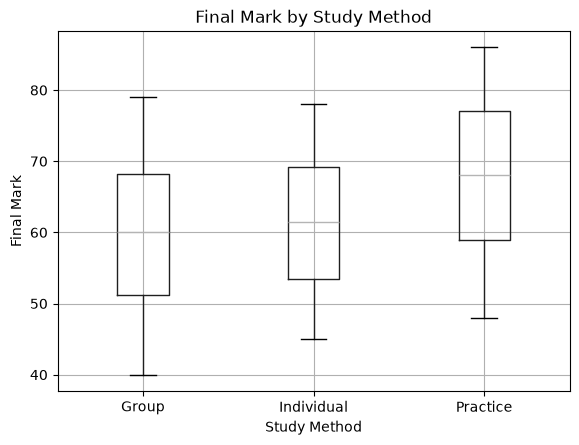

In [15]:
# ---------- BOXPLOT: STUDY METHOD ----------

plt.figure(figsize=(8, 5))

df.boxplot(
    column="Final Mark",
    by="Study Method"
)

plt.title("Final Mark by Study Method")
plt.suptitle("")
plt.xlabel("Study Method")
plt.ylabel("Final Mark")

plt.show()

In [16]:
# ---------- ONE-WAY ANOVA ----------

anova_model = ols(
    'Q("Final Mark") ~ C(Q("Study Method"))',
    data=df
).fit()

anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2
)

anova_table

,sum_sq,df,F,PR(>F)
"C(Q(""Study Method""))",342.6,2.0,1.200888,0.316496
Residual,3851.4,27.0,NaN,NaN


In [17]:
# ---------- CLEAN ANOVA TABLE ----------

anova_table = anova_table.rename(columns={
    "sum_sq": "SS",
    "df": "DF",
    "F": "F-statistic",
    "PR(>F)": "p-value"
})

anova_table["MS"] = anova_table["SS"] / anova_table["DF"]

anova_table = anova_table[
    ["DF", "SS", "MS", "F-statistic", "p-value"]
]

anova_table

,DF,SS,MS,F-statistic,p-value
"C(Q(""Study Method""))",2.0,342.6,171.300000,1.200888,0.316496
Residual,27.0,3851.4,142.644444,NaN,NaN


In [18]:
X = df["Study Hours"]
X = sm.add_constant(X)

Y = df["Final Mark"]

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             Final Mark   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     1482.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           8.56e-26
Time:                        18:04:19   Log-Likelihood:                -56.855
No. Observations:                  30   AIC:                             117.7
Df Residuals:                      28   BIC:                             120.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          31.5373      0.872     36.165      

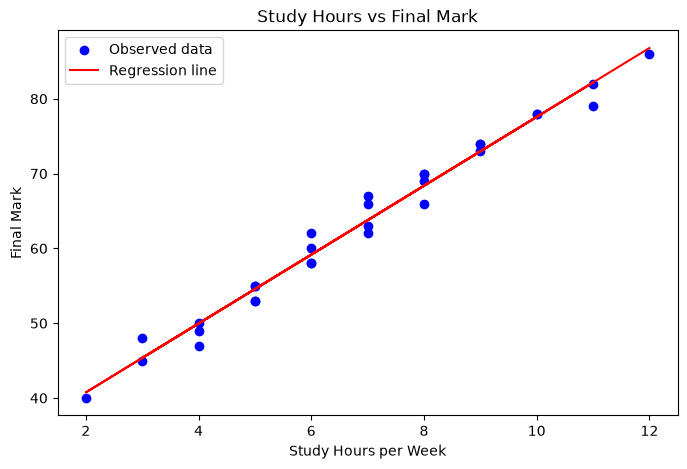

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Study Hours"],
    df["Final Mark"],
    color="blue",
    label="Observed data"
)

plt.plot(
    df["Study Hours"],
    model.fittedvalues,
    color="red",
    label="Regression line"
)

plt.title("Study Hours vs Final Mark")
plt.xlabel("Study Hours per Week")
plt.ylabel("Final Mark")
plt.legend()

plt.show()

In [20]:
# ---------- SIMPLE LINEAR REGRESSION ----------

X = df["Study Hours"]
X = sm.add_constant(X)

Y = df["Final Mark"]

regression_model = sm.OLS(Y, X).fit()

regression_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             Final Mark   R-squared:                       0.981
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     1482.
Date:                Mon, 21 Sep 2026   Prob (F-statistic):           8.56e-26
Time:                        18:04:19   Log-Likelihood:                -56.855
No. Observations:                  30   AIC:                             117.7
Df Residuals:                      28   BIC:                             120.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          31.5373      0.872     36.165      0.000      29.751      33.324
Study Hours     4.6043      0.120     38.498      0.000       4.359       4.849
==============================================================================
Omnibus:                        0.128   Durbin-Watson:                   1.857
Prob(Omnibus):                  0.938   Jarque-Bera (JB):                0.341
Skew:                           0.067   Prob(JB):                        0.843
Kurtosis:                       2.495   Cond. No.                         21.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

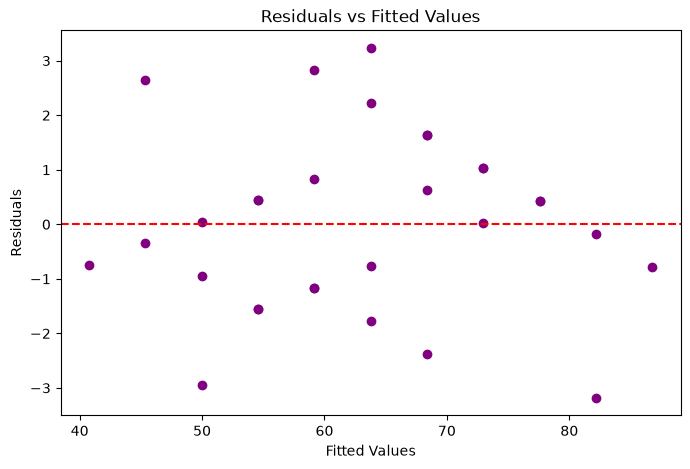

In [21]:
residuals = model.resid
fitted_values = model.fittedvalues

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    residuals,
    color="purple"
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.show()